In [1]:
"""
Solution for week 5 practice of Data Visualization

Code to read, trim, and save a digital elevation map for the Grand Canyon - https://pubs.usgs.gov/ds/121/grand/grand.html
Note that gc_dem.tiff uses a very old tiff format and needs to loaded using the tifffile module (not matplotlib)
"""

import numpy as np
import matplotlib.pyplot as plt
import tifffile

In [2]:
# Resource paths
DATA_PATH = "../data/"

# Constants used in processing original image
GC_ORIGINAL = DATA_PATH + "gc_dem.tiff"
GC_PROCESSED = DATA_PATH + "gc_dem_processed.tiff"
TRIM_REGION = np.s_[1500 : 3500, 2500 : 5500]
SCALE = 10
    

Original image has shape (3949, 6102)
Original image has entries of type uint16


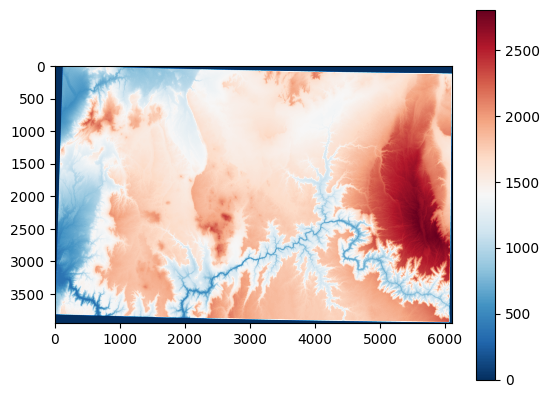

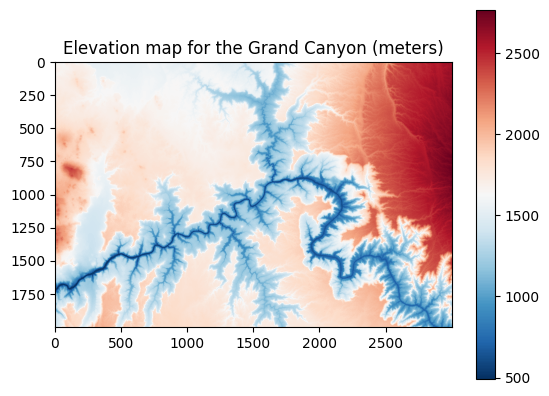

Saved processed DEM image of size 2000 by 3000
Reloaded image has entries of type uint16
True


In [ ]:
def process_dem():
    """
    Input:
    
    Action: Read, trim/scale, and save a digital elevation map for the Grand Canyon
    """
    
    # Read original file using imread(), verify dtype of loaded data
    #original_array = plt.imread(GC_ORIGINAL)               # matplotlib MAY raise an error due to very old tiff format
    original_array = tifffile.imread(GC_ORIGINAL)     # tifffile correctly reads old format
    print("Original image has shape", original_array.shape)
    print("Original image has entries of type", original_array.dtype)
    
    # Plot original DEM using matplotlib
    plt.imshow(original_array, cmap=plt.cm.RdBu_r)
    plt.colorbar()
    plt.show()
    
    # Trim original DEM to eliminate boundaries
    trimmed_array = original_array[TRIM_REGION]
    
    # Plot processed DEM using matplotlib
    plt.imshow(trimmed_array, cmap=plt.cm.RdBu_r)
    plt.title("Elevation map for the Grand Canyon (meters)")
    plt.colorbar()
    plt.show()
    
    # Save scaled numpy array as TIFF file for good contrast
    #plt.imwrite(GC_PROCESSED, trimmed_array * SCALE)         # matplotlib incorrectly saves as uint8 array     
    tifffile.imwrite(GC_PROCESSED, trimmed_array * SCALE)     # tifffile correcttly saves as uint16 array
    print("Saved processed DEM image of size", trimmed_array.shape[0], "by", trimmed_array.shape[1])
    
    # Check that saving and reloading data leaves dtype unchanged
    reloaded_array = plt.imread(GC_PROCESSED)          # matplotlib now reads uint16 correctly
    print("Reloaded image has entries of type", reloaded_array.dtype)
    print(np.array_equal(trimmed_array * SCALE, reloaded_array))
    
process_dem()